Device: cpu


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]


Upload an image for analysis:


Saving Screenshot 2025-08-18 141211.png to Screenshot 2025-08-18 141211.png

Enter a question about the uploaded image: What is this image?


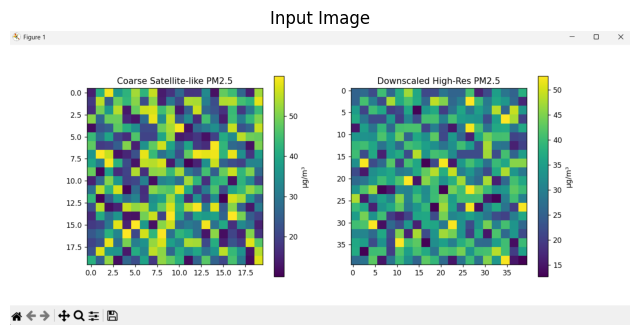


MULTIMODAL AI RESULT
--------------------------------------------------
Question: What is this image?
Answer: data


In [1]:
!pip install transformers torch pillow matplotlib sentencepiece -q

import torch
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from transformers import BlipProcessor,BlipForQuestionAnswering

device="cuda" if torch.cuda.is_available() else "cpu"
print("Device:",device)

model_name="Salesforce/blip-vqa-base"
processor=BlipProcessor.from_pretrained(model_name)
model=BlipForQuestionAnswering.from_pretrained(model_name).to(device)
model.eval()

print("\nUpload an image for analysis:")
uploaded_files=files.upload()

image_path=next(iter(uploaded_files))
image=Image.open(image_path).convert("RGB")

question=input("\nEnter a question about the uploaded image: ")

inputs=processor(
    images=image,
    text=question,
    return_tensors="pt"
)

inputs={
    key:value.to(device)
    for key,value in inputs.items()
}

with torch.no_grad():
    generated_ids=model.generate(
        **inputs,
        max_new_tokens=30
    )

answer=processor.decode(
    generated_ids[0],
    skip_special_tokens=True
)

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

print("\nMULTIMODAL AI RESULT")
print("-"*50)
print("Question:",question)
print("Answer:",answer)